# 2D U(1) Scaling Analysis

This notebook reads precomputed HMC and FT-HMC topology CSV files and makes the scaling performance comparison plot.

In [ ]:
import os
from pathlib import Path
import sys

import gvar as gv
import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "2du1").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from nthmc.core.plot_settings import color_ls, default_plot, errorb, errorb_circle, fs_p, fs_small_p
from nthmc.core.resampling import jackknife, jk_ls_avg
from nthmc.u1.u1_observables import autocorrelation_from_chi, format_beta

LATTICE_SIZES = [8, 16]
BETAS = [3.0, 4.0, 5.0]
SEEDS = [1029]
TRAIN_BETA = 3.0
N_STEPS = int(os.environ.get("NTHMC_SCALING_N_STEPS", "10"))
MAX_LAG = 20
GAMMA_LAG = 16
MODEL_TAG = "base"

HMC_DUMP_DIR = REPO_ROOT / "2du1" / "evaluation" / "hmc" / "dumps"
FTHMC_DUMP_DIR = REPO_ROOT / "2du1" / "evaluation" / "base" / "dumps"
PLOT_DIR = REPO_ROOT / "presentation" / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def scaling_save_tag(lattice_size, seed):
    train_beta_tag = format_beta(TRAIN_BETA)
    return f"{MODEL_TAG}_scaling_train_b{train_beta_tag}_L{lattice_size}_{seed}"


def hmc_topo_path(lattice_size, beta, seed):
    beta_tag = format_beta(beta)
    return HMC_DUMP_DIR / f"topo_hmc_L{lattice_size}_beta{beta_tag}_nsteps{N_STEPS}_{seed}.csv"


def fthmc_topo_path(lattice_size, beta, seed):
    beta_tag = format_beta(beta)
    save_tag = scaling_save_tag(lattice_size, seed)
    return FTHMC_DUMP_DIR / f"topo_fthmc_L{lattice_size}_beta{beta_tag}_nsteps{N_STEPS}_{save_tag}.csv"


def load_topology(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing topology CSV: {path}")
    return np.atleast_1d(np.loadtxt(path))


def delta_q(topology):
    if len(topology) < 2:
        return np.nan
    return float(np.mean(np.abs(np.diff(topology))))


def gamma_from_autocorrelation(autocorrelation):
    if GAMMA_LAG >= len(autocorrelation):
        return np.nan
    return 1.0 / (1.0 - autocorrelation[GAMMA_LAG])


def gamma_ratio_from_autocorrelations(hmc_autocorrelation, fthmc_autocorrelation):
    if GAMMA_LAG >= len(hmc_autocorrelation) or GAMMA_LAG >= len(fthmc_autocorrelation):
        return np.nan
    hmc_denom = 1.0 - hmc_autocorrelation[GAMMA_LAG]
    fthmc_denom = 1.0 - fthmc_autocorrelation[GAMMA_LAG]
    if np.isclose(gv.mean(hmc_denom), 0.0):
        return gv.gvar(np.inf, 0.0)
    return fthmc_denom / hmc_denom


def ratio_or_inf(numerator, denominator):
    if np.isclose(gv.mean(denominator), 0.0):
        return gv.gvar(np.inf, 0.0)
    return numerator / denominator


def average_pair_with_jackknife(hmc_values, fthmc_values):
    hmc_values = np.asarray(hmc_values, dtype=float)
    fthmc_values = np.asarray(fthmc_values, dtype=float)
    if len(hmc_values) == 1:
        hmc_avg = gv.gvar(hmc_values[0], np.zeros_like(hmc_values[0]))
        fthmc_avg = gv.gvar(fthmc_values[0], np.zeros_like(fthmc_values[0]))
        return hmc_avg, fthmc_avg

    joined = np.concatenate([hmc_values, fthmc_values], axis=1)
    joined_avg = jk_ls_avg(jackknife(joined))
    split = hmc_values.shape[1]
    return joined_avg[:split], joined_avg[split:]


def collect_one(lattice_size, beta):
    volume = lattice_size**2
    hmc_autos = []
    fthmc_autos = []
    hmc_delta_q = []
    fthmc_delta_q = []

    for seed in SEEDS:
        hmc_topo = load_topology(hmc_topo_path(lattice_size, beta, seed))
        fthmc_topo = load_topology(fthmc_topo_path(lattice_size, beta, seed))
        hmc_autos.append(autocorrelation_from_chi(hmc_topo, MAX_LAG, beta, volume))
        fthmc_autos.append(autocorrelation_from_chi(fthmc_topo, MAX_LAG, beta, volume))
        hmc_delta_q.append([delta_q(hmc_topo)])
        fthmc_delta_q.append([delta_q(fthmc_topo)])

    hmc_auto_avg, fthmc_auto_avg = average_pair_with_jackknife(hmc_autos, fthmc_autos)
    hmc_delta_avg, fthmc_delta_avg = average_pair_with_jackknife(hmc_delta_q, fthmc_delta_q)

    gamma_ratio = gamma_ratio_from_autocorrelations(hmc_auto_avg, fthmc_auto_avg)
    delta_q_ratio = ratio_or_inf(fthmc_delta_avg[0], hmc_delta_avg[0])
    return {
        "hmc_auto": hmc_auto_avg,
        "fthmc_auto": fthmc_auto_avg,
        "gamma_ratio": gamma_ratio,
        "delta_q_ratio": delta_q_ratio,
    }

In [3]:
results = {}
for lattice_size in LATTICE_SIZES:
    for beta in BETAS:
        results[(lattice_size, beta)] = collect_one(lattice_size, beta)
        print(
            f"L={lattice_size:>2}, beta={beta:.1f}, "
            f"R_gamma(16)={results[(lattice_size, beta)]['gamma_ratio']}, "
            f"R_deltaQ={results[(lattice_size, beta)]['delta_q_ratio']}"
        )

L= 8, beta=3.0, R_gamma(16)=0.936392(0), R_deltaQ=1.33086(0)
L= 8, beta=4.0, R_gamma(16)=1.733(0), R_deltaQ=1.77679(0)
L= 8, beta=5.0, R_gamma(16)=2.38857(0), R_deltaQ=2.53846(0)
L= 8, beta=6.0, R_gamma(16)=inf ± 0, R_deltaQ=inf ± 0
L=16, beta=3.0, R_gamma(16)=1.14364(0), R_deltaQ=1.39962(0)
L=16, beta=4.0, R_gamma(16)=2.41199(0), R_deltaQ=3.55838(0)
L=16, beta=5.0, R_gamma(16)=7.22177(0), R_deltaQ=4.77273(0)
L=16, beta=6.0, R_gamma(16)=inf ± 0, R_deltaQ=inf ± 0


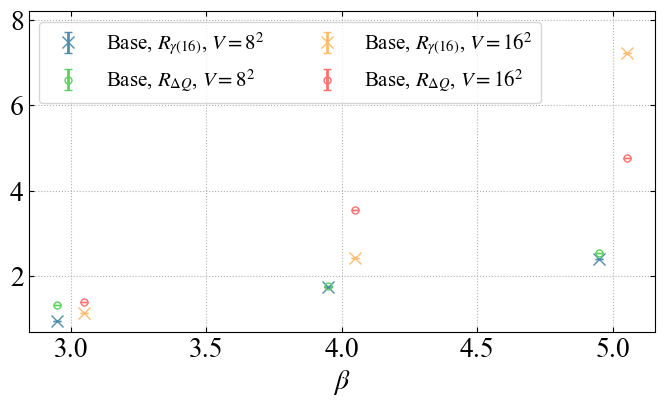

In [13]:
fig, ax = default_plot()
beta_values = np.array(BETAS, dtype=float)

for index, lattice_size in enumerate(LATTICE_SIZES):
    offset = -0.05 if index == 0 else 0.05
    gamma_ratios = [results[(lattice_size, beta)]["gamma_ratio"] for beta in BETAS]
    delta_q_ratios = [results[(lattice_size, beta)]["delta_q_ratio"] for beta in BETAS]

    ax.errorbar(
        beta_values + offset,
        gv.mean(gamma_ratios),
        yerr=gv.sdev(gamma_ratios),
        label=rf"Base, $R_{{\gamma (16)}}$, $V={lattice_size}^2$",
        color=color_ls[index],
        marker="x",
        **errorb,
    )
    ax.errorbar(
        beta_values + offset,
        gv.mean(delta_q_ratios),
        yerr=gv.sdev(delta_q_ratios),
        label=rf"Base, $R_{{\Delta Q}}$, $V={lattice_size}^2$",
        color=color_ls[index + len(LATTICE_SIZES)],
        **errorb_circle,
    )

ax.set_ylim(0.7, 8.2)
ax.legend(ncol=2, loc="upper left", fontsize=15)
ax.set_xlabel(r"$\beta$", **fs_p)
plt.tight_layout()
plt.savefig(PLOT_DIR / "scaling_performance.pdf", transparent=True)
plt.show()

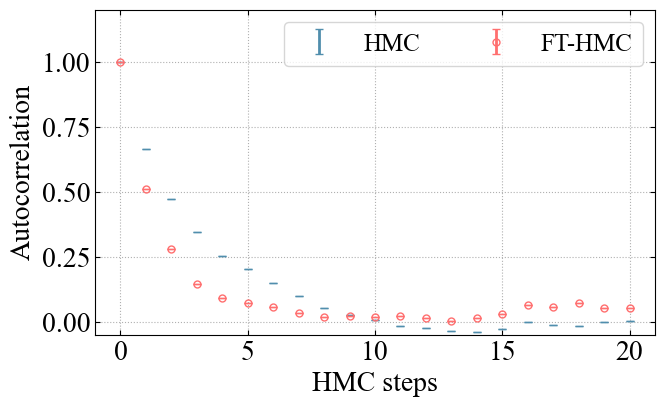

In [ ]:
SELECTED_L = 8
SELECTED_BETA = 3
curve = results[(SELECTED_L, SELECTED_BETA)]
lags = np.arange(MAX_LAG + 1)

fig, ax = default_plot()
ax.errorbar(lags, gv.mean(curve["hmc_auto"]), yerr=gv.sdev(curve["hmc_auto"]), label="HMC", color=color_ls[0], **errorb)
ax.errorbar(lags, gv.mean(curve["fthmc_auto"]), yerr=gv.sdev(curve["fthmc_auto"]), label="FT-HMC", color=color_ls[3], **errorb_circle)
ax.set_ylim(-0.05, 1.2)
ax.legend(ncol=2, loc="upper right", **fs_small_p)
ax.set_xlabel("HMC steps", **fs_p)
ax.set_ylabel("Autocorrelation", **fs_p)
plt.tight_layout()
plt.savefig(PLOT_DIR / f"scaling_autocorrelation_L{SELECTED_L}_b{format_beta(SELECTED_BETA)}.pdf", transparent=True)
plt.show()